In [1]:
import xarray as xr
import scipy.integrate as sc
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as cl

In [ ]:
# data0 = xr.open_dataset("stability_analysis_output_eleventh_twelfth.nc")
# data1 = xr.open_dataset("stability_analysis_output_twelth_twelfth.nc")
# data1.coords["strat_index"] = data1.coords["strat_index"]+1 #+1/250
# data2 = xr.open_dataset("stability_analysis_output_first_twelfth.nc")
# data2.coords["strat_index"] = data2.coords["strat_index"]+2 #+1/250
# data3 = xr.open_dataset("stability_analysis_output_second_twelfth.nc")
# data3.coords["strat_index"] = data3.coords["strat_index"]+3 #+1/250
# data4 = xr.open_dataset("stability_analysis_output_third_twelfth.nc")
# data4.coords["strat_index"] = data4.coords["strat_index"]+4 #+1/250
# data5 = xr.open_dataset("stability_analysis_output_fourth_twelfth.nc")
# data5.coords["strat_index"] = data5.coords["strat_index"]+5 #+1/250
# data6 = xr.open_dataset("stability_analysis_output_fifth_twelfth.nc")
# data6.coords["strat_index"] = data6.coords["strat_index"]+6 #+1/250
# data7 = xr.open_dataset("stability_analysis_output_sixth_twelfth.nc")
# data7.coords["strat_index"] = data7.coords["strat_index"]+7 #+1/250
# data8 = xr.open_dataset("stability_analysis_output_seventh_twelfth.nc")
# data8.coords["strat_index"] = data8.coords["strat_index"]+8 #+1/250
# data9 = xr.open_dataset("stability_analysis_output_eighth_twelfth.nc")
# data9.coords["strat_index"] = data9.coords["strat_index"]+9 #+1/250
# data10 = xr.open_dataset("stability_analysis_output_ninth_twelfth.nc")
# data10.coords["strat_index"] = data8.coords["strat_index"]+10 #+1/250
# data11 = xr.open_dataset("stability_analysis_output_tenth_twelfth.nc")
# data11.coords["strat_index"] = data9.coords["strat_index"]+11 #+1/250
# # data = xr.concat([data0,data1],dim="strat_index")
# data = xr.concat([data0,data1.isel(strat_index=slice(1,None))],dim="strat_index")
# data = xr.concat([data,data2.isel(strat_index=slice(1,None))],dim="strat_index")
# data = xr.concat([data,data3.isel(strat_index=slice(1,None))],dim="strat_index")
# data = xr.concat([data,data4.isel(strat_index=slice(1,None))],dim="strat_index")
# data = xr.concat([data,data5.isel(strat_index=slice(1,None))],dim="strat_index")
# data = xr.concat([data,data6.isel(strat_index=slice(1,None))],dim="strat_index")
# data = xr.concat([data,data7.isel(strat_index=slice(1,None))],dim="strat_index")
# data = xr.concat([data,data8.isel(strat_index=slice(1,None))],dim="strat_index")
# data = xr.concat([data,data9.isel(strat_index=slice(1,None))],dim="strat_index")
# data = xr.concat([data,data10.isel(strat_index=slice(1,None))],dim="strat_index")
# data = xr.concat([data,data11.isel(strat_index=slice(1,None))],dim="strat_index")
# # # data = xr.concat([data,data2],dim="strat_index")

In [ ]:
# data.to_netcdf("data_small_angle_super_high_res.nc")

In [2]:
data = xr.open_dataset("stability_analysis_output_twelth_twelfth.nc")

In [3]:
# data_Sinf_gamma_space = xr.open_dataset("stability_analysis_output_high_Sinf_res_hold_delta.nc")
# data_Sinf_gamma_space

In [4]:
data

<xarray.Dataset> Size: 751kB
Dimensions:              (delta: 200, slope_burger_number: 39, strat_index: 3)
Coordinates:
  * delta                (delta) float64 2kB 0.0 0.00505 0.0101 ... 0.9999 1.005
  * slope_burger_number  (slope_burger_number) float64 312B 0.05 0.1 ... 1.95
  * strat_index          (strat_index) float64 24B 0.0 0.5 1.0
Data variables:
    growth_rate          (slope_burger_number, delta, strat_index) float64 187kB ...
    frequency            (slope_burger_number, delta, strat_index) float64 187kB ...
    slope_angle          (slope_burger_number, delta, strat_index) float64 187kB ...
    strat_values         (slope_burger_number, delta, strat_index) float64 187kB ...

In [41]:
gamma_choice = data.strat_values.isel(slope_burger_number=10)
Sinf = data.slope_burger_number[10]
freq_ratio = (1-gamma_choice)*(1+Sinf**2)/(1-gamma_choice*(1+Sinf**2))

In [36]:
# Sinf = data.slope_burger_number
# theta = data.theta
# Sinf = total_data.sl
strat_values = data.strat_values
Riinv = Sinf**2/((1-strat_values)*(1+Sinf**2))
N2 = 1e-5

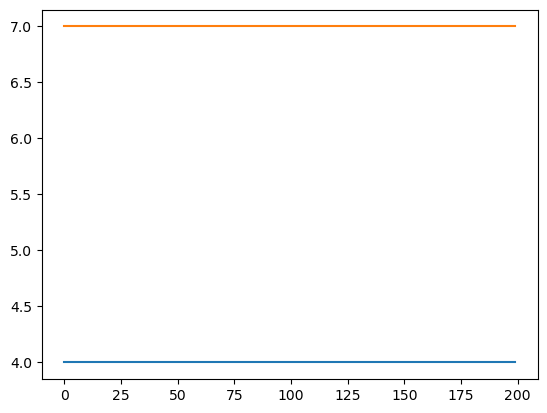

In [37]:
plt.plot(freq_ratio)

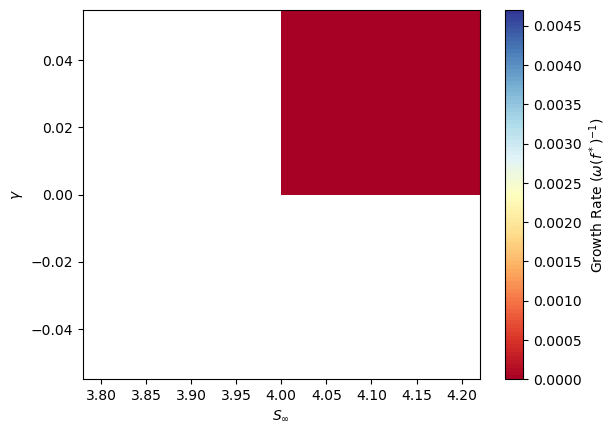

In [46]:
ti = 0
plt.contourf(freq_ratio,np.array([data.delta]).T*np.ones(np.shape(data.growth_rate.isel(slope_burger_number=ti))),data.growth_rate.isel(slope_burger_number=ti),levels=100,cmap="RdYlBu")
plt.colorbar(label=r"Growth Rate ($ \omega (f^*)^{-1}$)")
plt.contour(freq_ratio,np.array([data.delta]).T*np.ones(np.shape(data.growth_rate.isel(slope_burger_number=ti))),data.frequency.isel(slope_burger_number=ti),levels=[0.4999],cmap="gray")
# plt.vlines(1,0.4,0.61)
plt.xlabel(r"$S_\infty$")
plt.ylabel(r"$\gamma$")
# plt.savefig("growth_rate_zoom_in.jpeg")
plt.show()

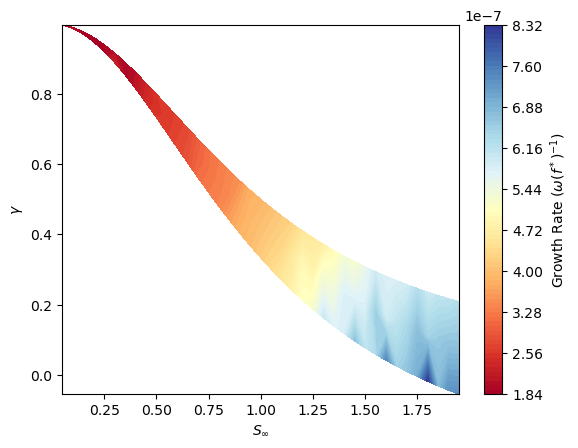

In [47]:
ti = 0
plt.contourf(np.array([data.slope_burger_number]).T*np.ones(np.shape(data.growth_rate.isel(delta=ti))),data.strat_values.isel(delta=ti),data.growth_rate.isel(delta=ti),levels=100,cmap="RdYlBu")
plt.colorbar(label=r"Growth Rate ($ \omega (f^*)^{-1}$)")
plt.contour(np.array([data.slope_burger_number]).T*np.ones(np.shape(data.growth_rate.isel(delta=ti))),data.strat_values.isel(delta=ti),data.frequency.isel(delta=ti),levels=[0.49],cmap="gray")
# plt.vlines(1,0.4,0.61)
plt.xlabel(r"$S_\infty$")
plt.ylabel(r"$\gamma$")
# plt.savefig("growth_rate_zoom_in.jpeg")
plt.show()

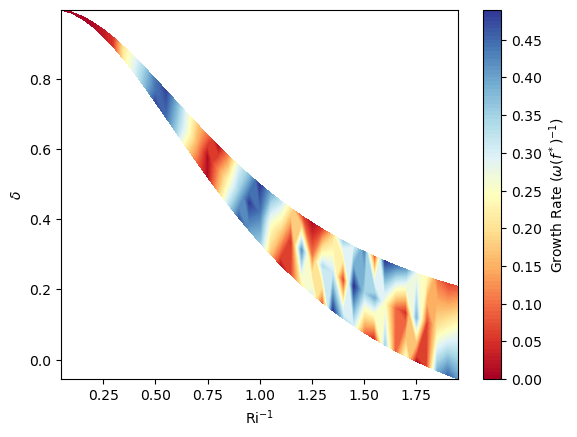

In [48]:
plt.contourf(np.array([data.slope_burger_number]).T*np.ones(np.shape(data.growth_rate.isel(delta=ti))),data.strat_values.isel(delta=ti),data.frequency.isel(delta=ti),levels=100,cmap="RdYlBu")
plt.colorbar(label=r"Growth Rate ($ \omega (f^*)^{-1}$)")
plt.xlabel(r"$\text{Ri}^{-1}$")
plt.ylabel(r"$\delta$")
plt.savefig("growth_rate.jpeg")
plt.show()

In [49]:
ti = 1
plt.contourf(Sinf[ti]**2/((1-strat_values.isel(slope_burger_number=ti))*(1+Sinf[ti]**2)),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.growth_rate.isel(slope_burger_number=ti),levels=100,cmap="RdYlBu")
plt.colorbar(label=r"Growth Rate ($ \omega (f^*)^{-1}$)")
plt.contour(Sinf[ti]**2/((1-strat_values.isel(slope_burger_number=ti))*(1+Sinf[ti]**2)),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.frequency.isel(slope_burger_number=ti),levels=[0.49999],cmap="gray")
# plt.vlines(1,0.4,0.61)
plt.xlabel(r"$\text{Ri}^{-1}$")
plt.ylabel(r"$\delta$")
# plt.savefig("growth_rate_zoom_in.jpeg")
plt.show()

IndexError: too many indices

In [ ]:
ti = 0
plt.contourf(strat_values.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.growth_rate.isel(slope_burger_number=ti),levels=400,cmap="RdYlBu")
plt.colorbar(label=r"Growth Rate ($ \omega (f^*)^{-1}$)")
plt.contour(strat_values.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.frequency.isel(slope_burger_number=ti),levels=[0.499999999],cmap="gray")
# plt.vlines(1,0.4,0.61)
plt.xlabel(r"$\text{Ri}^{-1}$")
plt.ylabel(r"$\delta$")
# plt.savefig("growth_rate_zoom_in.jpeg")
plt.show()

In [ ]:
ti = 0
plt.contourf(Riinv.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.growth_rate.isel(slope_burger_number=ti),levels=500,cmap="RdYlBu")
plt.colorbar(label=r"Growth Rate ($ \omega (f^*)^{-1}$)")
plt.contour(Riinv.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.frequency.isel(slope_burger_number=ti),levels=[0.4999],cmap="gray")
# plt.vlines(1,0.4,0.61)
plt.xlabel(r"$\text{Ri}^{-1}$")
plt.ylabel(r"$\delta$")
# plt.savefig("growth_rate_zoom_in.jpeg")
plt.show()

In [ ]:
ti = 1
WSPy_GSP = data.delta*(strat_values.isel(slope_burger_number=ti))/(1-strat_values.isel(slope_burger_number=ti))
plt.contourf(Riinv.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),WSPy_GSP,levels=100,cmap="RdYlBu")
plt.colorbar(label=r"Growth Rate ($ \omega (f^*)^{-1}$)")


In [ ]:
data.strat_values.isel(slope_burger_number=ti,delta=0)

In [ ]:
plt.plot(data.strat_index)

In [ ]:
# data.strat_values.isel(slope_burger_number=ti).plot()
plt.plot(data.strat_index[0:-98],data.strat_values.isel(slope_burger_number=ti,delta=50)[0:-98])


In [ ]:
ti = 0
mean_angle = -((1-data.strat_values.isel(slope_burger_number=ti))/(0.1))
plt.contourf(Riinv.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.slope_angle.isel(slope_burger_number=ti)/mean_angle,levels=500,cmap="RdYlBu")
plt.colorbar(label=r"Slope Angle Normalized")
plt.contour(Riinv.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.frequency.isel(slope_burger_number=ti),levels=[0.495],cmap="gray")
plt.xlabel(r"$\text{Ri}^{-1}$")
plt.ylabel(r"$\delta$")
# plt.savefig("slope_angle_norm.jpeg")
plt.show()

In [ ]:
ti = 0
mean_angle = -((1-data.strat_values.isel(slope_burger_number=ti))/(0.1))
plt.contourf(Riinv.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),mean_angle,levels=100,cmap="RdYlBu")
plt.colorbar(label=r"Slope Angle Normalized")
plt.contour(Riinv.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.frequency.isel(slope_burger_number=ti),levels=[0.495],cmap="gray")
plt.xlabel(r"$\text{Ri}^{-1}$")
plt.ylabel(r"$\delta$")
# plt.savefig("slope_angle_norm.jpeg")
plt.show()

In [ ]:
ti = 1
plt.contourf(Riinv.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.slope_angle.isel(slope_burger_number=ti),levels=100,cmap="RdYlBu")
plt.colorbar(label=r"Slope Angle")
plt.contour(Riinv.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.frequency.isel(slope_burger_number=ti),levels=[0.49],cmap="gray")
plt.xlabel(r"$\text{Ri}^{-1}$")
plt.ylabel(r"$\delta$")
# plt.savefig("slope_angle.jpeg")
plt.show()

In [ ]:
ti = 0
plt.contourf(Riinv.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.growth_rate.isel(slope_burger_number=ti),levels=100,cmap="RdYlBu")
plt.colorbar(label=r"Growth Rate ($ \omega (f^*)^{-1}$)")
plt.contour(Riinv.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.frequency.isel(slope_burger_number=ti),levels=[0.49],cmap="gray")

plt.xlabel(r"$\text{Ri}^{-1}$")
plt.ylabel(r"$\delta$")
plt.savefig("growth_rate.jpeg")
plt.show()

In [ ]:
ti = 1
plt.contourf(Riinv.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),mean_angle,levels=100,cmap="RdYlBu")
plt.colorbar(label=r"$\mu_o/\mu_B$")
plt.xlabel(r"$\text{Ri}^{-1}$")
plt.ylabel(r"$\delta$")
plt.savefig("slope_angle.jpeg")
plt.show()

In [ ]:
plt.contourf(Riinv.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.slope_angle.isel(slope_burger_number=ti)/mean_angle,levels=100,cmap="RdYlBu")
plt.colorbar(label=r"$\mu_o/\mu_B$")
plt.xlabel(r"$\text{Ri}^{-1}$")
plt.ylabel(r"$\delta$")
plt.savefig("slope_angle.jpeg")
plt.show()

In [ ]:
ti = 0
plt.contourf(Riinv.isel(slope_burger_number=ti),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=ti))),data.frequency.isel(slope_burger_number=ti),levels=100,cmap="RdYlBu")
plt.colorbar(label=r"Growth Rate ($ \omega (f^*)^{-1}$)")
plt.xlabel(r"$\text{Ri}^{-1}$")
plt.ylabel(r"$\delta$")
plt.savefig("growth_rate.jpeg")
plt.show()

In [ ]:
def m_t(t, m, fstar, delta, lmbd, phi):
    # print(m+delta*lmbd/(fstar)*np.sin(t+phi))
    return m+delta*lmbd/(fstar)*np.sin(t+phi)

In [ ]:
def PSI_system(v,t,m,theta,gm,S2,delta,lmbd,phi):
    psi, D = v
    fstar = f*np.cos(theta)*(1+S2)**(0.5)
    A0 = (np.tan(theta)**2-S2)/(np.tan(theta)*(1+S2))*(m-np.tan(theta)*(np.tan(theta)**2-S2)**(-1)*((S2/(np.tan(theta)**2))*(1-gm*np.cos(theta)**(-4))+np.tan(theta)**2))
    A1 = m+(S2-np.tan(theta)**2)*(np.tan(theta)*(1+S2))**(-1)
    dpsidt = (A0-A1*m_t(t,m,fstar,delta,lmbd,phi))*D
    dDdt = (1+m_t(t,m,fstar,delta,lmbd,phi)**2)**(-1)*psi
    return [dpsidt, dDdt]

In [ ]:
tau = 2*np.pi
dt = 500
phi = np.pi/2
# d_di = 12
f = 1e-4
theta = 0.1
strt_ind = 25
j = 20
t = np.linspace(0, tau+1/dt, dt)
WSPRT = []
WSPxRT = []
WSPyRT = []
BFLUXRT = []
BFLUXxRT = []
BFLUXzRT = []
GSPRT = []
ke_l = []
q = 0
for j in range(len(data.slope_burger_number)):
    WSPRT3 = []
    WSPxRT3 = []
    WSPyRT3 = []
    BFLUXRT3 = []
    BFLUXxRT3 = []
    BFLUXzRT3 = []
    GSPRT3 = []
    ke_l3 = []
    for i in range(len(data.strat_values.isel(delta=0,slope_burger_number=j))):
        WSPRT2 = []
        WSPxRT2 = []
        WSPyRT2 = []
        BFLUXRT2 = []
        BFLUXxRT2 = []
        BFLUXzRT2 = []
        GSPRT2 = []
        ke_l2 = []
        S2 = data.slope_burger_number[j].values**2
        N2 = S2*f**2/theta**2
        for d_di in range(len(data.delta)):
            delta = data.delta[d_di].values
            gm = data.strat_values.isel(delta=d_di,slope_burger_number=j,strat_index=i).values
            m_max = data.slope_angle.isel(delta=d_di,slope_burger_number=j,strat_index=i).values
            lmbd = N2*theta*gm/f
            sol = sc.odeint(PSI_system, [0, 1], t, args=(m_max, theta, gm, S2, delta, lmbd, phi))
            n = (f*(1+S2)**(0.5)/lmbd)
            beta = (1+S2)**(0.5)
            alpha = N2*(1-gm)*theta/(f*lmbd)
            Ri = N2*(1-gm)/lmbd**2
            fstar = f*beta
            w = ((m_t(t, m_max, fstar, delta, lmbd, phi))**2+1)**(-1)*sol[:,0]
            u = m_t(t, m_max, fstar, delta, lmbd, phi)*w*n
            v = -f*(gm*S2/theta-theta+m_max)*sol[:,1]/(lmbd)
            b = -N2*theta*(m_max+(1-gm)/theta)*sol[:,1]/(N2*(1-gm))
            ke = 0.5*(u**2+v**2+n**2*w**2)
            BFLUX = alpha*beta**(-1)*u*b+w*b*Ri
            BFLUX_int = sc.simpson(BFLUX,x=t)
            BFLUXx = alpha*beta**(-1)*u*b
            BFLUXx_int = sc.simpson(BFLUXx,x=t)
            BFLUXz = w*b*Ri
            BFLUXz_int = sc.simpson(BFLUXz,x=t)
            GSP = -v*w
            GSP_int = sc.simpson(GSP,x=t)
            WSP = -u*w*delta*np.cos(t+phi)+v*w*(f*delta/fstar*np.sin(t+phi))
            WSP_int = sc.simpson(WSP,x=t)
            WSPx = -u*w*delta*np.cos(t+phi)
            WSPx_int = sc.simpson(WSPx,x=t)
            WSPy = v*w*(f*delta/fstar*np.sin(t+phi))
            WSPy_int = sc.simpson(WSPy,x=t)
            # ke = BFLUX_int+GSP_int+WSP_int
            WSPRT2.append((WSP_int)/(ke[-1]-ke[0]))
            WSPxRT2.append((WSPx_int)/(ke[-1]-ke[0]))
            WSPyRT2.append((WSPy_int)/(ke[-1]-ke[0]))
            BFLUXRT2.append((BFLUX_int)/(ke[-1]-ke[0]))
            BFLUXxRT2.append((BFLUXx_int)/(ke[-1]-ke[0]))
            BFLUXzRT2.append((BFLUXz_int)/(ke[-1]-ke[0]))
            GSPRT2.append((GSP_int)/(ke[-1]-ke[0]))
            ke_l2.append(ke[-1]-ke[0])
        WSPRT3.append(WSPRT2)
        WSPxRT3.append(WSPxRT2)
        WSPyRT3.append(WSPyRT2)
        BFLUXRT3.append(BFLUXRT2)
        BFLUXxRT3.append(BFLUXxRT2)
        BFLUXzRT3.append(BFLUXzRT2)
        GSPRT3.append(GSPRT2)
        ke_l3.append(ke_l2)
    WSPRT.append(WSPRT3)
    WSPxRT.append(WSPxRT3)
    WSPyRT.append(WSPyRT3)
    BFLUXRT.append(BFLUXRT3)
    BFLUXxRT.append(BFLUXxRT3)
    BFLUXzRT.append(BFLUXzRT3)
    GSPRT.append(GSPRT3)
    ke_l.append(ke_l3)
WSPRT = np.array(WSPRT)
WSPxRT = np.array(WSPxRT)
WSPyRT = np.array(WSPyRT)
BFLUXRT = np.array(BFLUXRT)
BFLUXxRT = np.array(BFLUXxRT)
BFLUXzRT = np.array(BFLUXzRT)
GSPRT = np.array(GSPRT)
ke_l = np.array(ke_l)

In [ ]:
np.shape(WSPRT)

In [ ]:
Riinv.isel(slope_burger_number=j).T

In [ ]:
# WSPRT_cleaned = WSPRT.copy()
# WSPRT_cleaned[np.isclose(data.frequency,0.5)]=0

In [ ]:
# data_copy = data.growth_rate.isel(theta=ti).copy()

In [ ]:
np.shape(WSPRT)

In [ ]:
Riinv.isel(slope_burger_number=0,delta=12)[45]

In [ ]:
data.delta[12]

In [ ]:
WSPRT[0,10,16]*ke_l[0,10,16]

In [ ]:
ke_l[0,0,16]

In [ ]:
WSPRT[0,45,16]*ke_l[0,45,16]

In [ ]:
ke_l[0,10,16]

In [ ]:
fig, ax = plt.subplots()
max = 5
levels= np.linspace(-max,max+1/100,100)

tj = 0
cf = ax.contourf(Riinv.isel(slope_burger_number=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),WSPRT[tj,:,:], levels=levels, cmap='seismic')

# Add colorbar with same limits
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("TKE contribution")
# cbar.set_ticks(np.linspace(vmin, vmax, 5))

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(8, 3),sharey=True,layout="constrained")  # 1 row, 3 columns
max = 0.3
levels= 100 #np.linspace(0,max+1/100,100)

tj = 2
s_ti = 0
s_tf = -1

# Plot on each subplot
cf = axs[0].contourf(Riinv.isel(slope_burger_number=0,strat_index=slice(s_ti,s_tf)),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=0,strat_index=slice(s_ti,s_tf)))),data.growth_rate.isel(slope_burger_number=0,strat_index=slice(s_ti,s_tf)), levels=levels,vmax=max, cmap='YlOrRd')
axs[0].contour(Riinv.isel(slope_burger_number=0,strat_index=slice(s_ti,s_tf)),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=0,strat_index=slice(s_ti,s_tf)))),data.frequency.isel(slope_burger_number=0,strat_index=slice(s_ti,s_tf)),levels=[0.4999],cmap="gray")


axs[1].contourf(Riinv.isel(slope_burger_number=1,strat_index=slice(s_ti,s_tf)),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=1,strat_index=slice(s_ti,s_tf)))),data.growth_rate.isel(slope_burger_number=1,strat_index=slice(s_ti,s_tf)), levels=levels,vmax=max, cmap='YlOrRd')
axs[1].contour(Riinv.isel(slope_burger_number=1,strat_index=slice(s_ti,s_tf)),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=1,strat_index=slice(s_ti,s_tf)))),data.frequency.isel(slope_burger_number=1,strat_index=slice(s_ti,s_tf)),levels=[0.4999],cmap="gray")

axs[2].contourf(Riinv.isel(slope_burger_number=2,strat_index=slice(s_ti,s_tf)),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=2,strat_index=slice(s_ti,s_tf)))),data.growth_rate.isel(slope_burger_number=2,strat_index=slice(s_ti,s_tf)), levels=levels,vmax=max, cmap='YlOrRd')
axs[2].contour(Riinv.isel(slope_burger_number=2,strat_index=slice(s_ti,s_tf)),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=2,strat_index=slice(s_ti,s_tf)))),data.frequency.isel(slope_burger_number=2,strat_index=slice(s_ti,s_tf)),levels=[0.4999],cmap="gray")

axs[0].text(0.51,1.05,"(a.)")
axs[1].text(0.51,1.05,"(b.)")
axs[2].text(0.51,1.05,"(c.)")

axs[0].set_xlabel(r"$\text{Ri}_{\text{HT}}^{-1}$")
axs[1].set_xlabel(r"$\text{Ri}_{\text{HT}}^{-1}$")
axs[2].set_xlabel(r"$\text{Ri}_{\text{HT}}^{-1}$")

axs[0].set_ylabel(r"$\delta$")


cbar = fig.colorbar(cf, ax=axs[2],ticks=np.arange(0,max+0.06,0.05))
cbar.set_label(r"Growth Rate ($\omega (f^*)^{-1}$)")
# Adjust layout
# plt.tight_layout()
plt.savefig("growth_rate_var_Sinf.jpeg",dpi=300)
plt.show()

In [ ]:
mean_angle_1

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(8, 3),sharey=True,layout="constrained")  # 1 row, 3 columns
max = 3
levels= np.linspace(0,max+1/100,100)

mean_angle_1 = -((1-data.strat_values.isel(slope_burger_number=0,strat_index=slice(s_ti,s_tf)))/(0.1))
mean_angle_2 = -((1-data.strat_values.isel(slope_burger_number=1,strat_index=slice(s_ti,s_tf)))/(0.1))
mean_angle_3 = -((1-data.strat_values.isel(slope_burger_number=2,strat_index=slice(s_ti,s_tf)))/(0.1))

# tj = 2
s_ti = 0
s_tf = -1

# Plot on each subplot
cf = axs[0].contourf(Riinv.isel(slope_burger_number=0,strat_index=slice(s_ti,s_tf)),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=0,strat_index=slice(s_ti,s_tf)))),data.slope_angle.isel(slope_burger_number=0,strat_index=slice(s_ti,s_tf))/mean_angle_1, levels=levels,vmin=0, vmax=max, cmap='YlOrRd')
axs[0].contour(Riinv.isel(slope_burger_number=0,strat_index=slice(s_ti,s_tf)),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=0,strat_index=slice(s_ti,s_tf)))),data.frequency.isel(slope_burger_number=0,strat_index=slice(s_ti,s_tf)),levels=[0.49999],cmap="gray")


axs[1].contourf(Riinv.isel(slope_burger_number=1,strat_index=slice(s_ti,s_tf)),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=1,strat_index=slice(s_ti,s_tf)))),data.slope_angle.isel(slope_burger_number=1,strat_index=slice(s_ti,s_tf))/mean_angle_2, levels=levels, vmax=max, cmap='YlOrRd')
axs[1].contour(Riinv.isel(slope_burger_number=1,strat_index=slice(s_ti,s_tf)),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=1,strat_index=slice(s_ti,s_tf)))),data.frequency.isel(slope_burger_number=1,strat_index=slice(s_ti,s_tf)),levels=[0.49999],cmap="gray")

axs[2].contourf(Riinv.isel(slope_burger_number=2,strat_index=slice(s_ti,s_tf)),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=2,strat_index=slice(s_ti,s_tf)))),data.slope_angle.isel(slope_burger_number=2,strat_index=slice(s_ti,s_tf))/mean_angle_3, levels=levels, vmax=max, cmap='YlOrRd')
axs[2].contour(Riinv.isel(slope_burger_number=2,strat_index=slice(s_ti,s_tf)),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=2,strat_index=slice(s_ti,s_tf)))),data.frequency.isel(slope_burger_number=2,strat_index=slice(s_ti,s_tf)),levels=[0.49999],cmap="gray")

axs[0].text(0.51,1.05,"(a.)")
axs[1].text(0.51,1.05,"(b.)")
axs[2].text(0.51,1.05,"(c.)")

axs[0].set_xlabel(r"$\text{Ri}_{\text{HT}}^{-1}$")
axs[1].set_xlabel(r"$\text{Ri}_{\text{HT}}^{-1}$")
axs[2].set_xlabel(r"$\text{Ri}_{\text{HT}}^{-1}$")

axs[0].set_ylabel(r"$\delta$")


cbar = fig.colorbar(cf, ax=axs[2], ticks=np.arange(0,max+0.5,0.5))
# cbar.set_clim(0,max)
cbar.set_label(r"$\mu_o/\mu_B$")
# Adjust layout
# plt.tight_layout()
plt.savefig("slope_angle_var_Sinf.jpeg",dpi=300)
plt.show()

In [ ]:
fig, ax = plt.subplots()
max = 5
levels= np.linspace(-max,max+1/100,100)
levels2= np.linspace(-max,max+1/100,20)

tj = 0
cf = ax.contourf(Riinv.isel(slope_burger_number=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),WSPxRT[tj,:,:], levels=levels, cmap='seismic')
# ax.contour(Riinv.isel(theta=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),WSPxRT[tj,:,:], levels=levels2,colors="black")

# Add colorbar with same limits
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("TKE contribution")
# cbar.set_ticks(np.linspace(vmin, vmax, 5))

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(8, 3),sharey=True,layout="constrained")  # 1 row, 3 columns
max = 3
levels = np.linspace(-max,max+1/100,100)

tj = 1

# Plot on each subplot
cf = axs[0].contourf(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,np.array([data.delta])*np.ones(np.shape(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)))).T,WSPRT[tj,s_ti:s_tf,:], levels=levels, cmap='seismic')
axs[0].contour(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,np.array([data.delta])*np.ones(np.shape(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)))).T,data.frequency.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,levels=[0.4999],cmap="gray")

axs[1].contourf(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,np.array([data.delta])*np.ones(np.shape(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)))).T,BFLUXRT[tj,s_ti:s_tf,:], levels=levels, cmap='seismic')
axs[1].contour(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,np.array([data.delta])*np.ones(np.shape(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)))).T,data.frequency.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,levels=[0.4999],cmap="gray")

axs[2].contourf(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,np.array([data.delta])*np.ones(np.shape(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)))).T,GSPRT[tj,s_ti:s_tf,:], levels=levels, cmap='seismic')
axs[2].contour(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,np.array([data.delta])*np.ones(np.shape(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)))).T,data.frequency.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,levels=[0.4999],cmap="gray")

axs[0].text(0.51,1.05,"(a.)")
axs[1].text(0.51,1.05,"(b.)")
axs[2].text(0.51,1.05,"(c.)")

axs[0].set_xlabel(r"$\text{Ri}_{\text{HT}}^{-1}$")
axs[1].set_xlabel(r"$\text{Ri}_{\text{HT}}^{-1}$")
axs[2].set_xlabel(r"$\text{Ri}_{\text{HT}}^{-1}$")

axs[0].set_ylabel(r"$\delta$")


cbar = fig.colorbar(cf, ax=axs[2],ticks=np.arange(-max,max+0.25,1))
# cbar.set_label("TKE contribution")
# Adjust layout
# plt.tight_layout()
plt.savefig("TKE_term_relative_contr.jpeg",dpi=300)
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(8, 3),sharey=True,layout="constrained")  # 1 row, 3 columns
max = 3
levels= np.linspace(-max,max+1/100,100)

tj = 1

# Plot on each subplot
cf = axs[2].contourf(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,np.array([data.delta])*np.ones(np.shape(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)))).T,GSPRT[tj,s_ti:s_tf,:], levels=levels, cmap='seismic')
axs[2].contour(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,np.array([data.delta])*np.ones(np.shape(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)))).T,data.frequency.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,levels=[0.4999],cmap="gray")

axs[1].contourf(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,np.array([data.delta])*np.ones(np.shape(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)))).T,BFLUXRT[tj,s_ti:s_tf,:], levels=levels, cmap='seismic')
axs[1].contour(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,np.array([data.delta])*np.ones(np.shape(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)))).T,data.frequency.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,levels=[0.4999],cmap="gray")

axs[0].contourf(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,np.array([data.delta])*np.ones(np.shape(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)))).T,GSPRT[tj,s_ti:s_tf,:]+BFLUXRT[tj,s_ti:s_tf,:], levels=levels, cmap='seismic')
axs[0].contour(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,np.array([data.delta])*np.ones(np.shape(Riinv.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)))).T,data.frequency.isel(slope_burger_number=tj,strat_index=slice(s_ti,s_tf)).T,levels=[0.4999],cmap="gray")

axs[0].text(0.51,1.05,"(a.)")
axs[1].text(0.51,1.05,"(b.)")
axs[2].text(0.51,1.05,"(c.)")

axs[0].set_ylabel(r"$\delta$")

axs[0].set_xlabel(r"$\text{Ri}_{\text{HT}}^{-1}$")
axs[1].set_xlabel(r"$\text{Ri}_{\text{HT}}^{-1}$")
axs[2].set_xlabel(r"$\text{Ri}_{\text{HT}}^{-1}$")

cbar = fig.colorbar(cf, ax=axs[2],ticks=np.arange(-max,max+1,1))
# cbar.set_label("TKE contribution")
# Adjust layout
# plt.tight_layout()
plt.savefig("TKE_term_GSP_BFLUX.jpeg",dpi=300)
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(8, 3),sharey=True,layout="constrained")  # 1 row, 3 columns
max = 3
levels= np.linspace(-max,max+1/100,100)
levels2= np.linspace(-max,max+1/100,25)

tj = 0

# Plot on each subplot
cf = axs[0].contourf(Riinv.isel(slope_burger_number=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),WSPRT[tj,:,:], levels=levels, cmap='seismic')
axs[0].contour(Riinv.isel(slope_burger_number=tj),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=tj))),data.frequency.isel(slope_burger_number=tj),levels=[0.49],cmap="gray")

axs[1].contourf(Riinv.isel(slope_burger_number=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),WSPxRT[tj,:,:], levels=levels, cmap='seismic')
axs[1].contour(Riinv.isel(slope_burger_number=tj),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=tj))),data.frequency.isel(slope_burger_number=tj),levels=[0.49],cmap="gray")

axs[2].contourf(Riinv.isel(slope_burger_number=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),WSPyRT[tj,:,:], levels=levels, cmap='seismic')
axs[2].contour(Riinv.isel(slope_burger_number=tj),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=tj))),data.frequency.isel(slope_burger_number=tj),levels=[0.49],cmap="gray")

axs[0].text(0.51,1.05,"(a.)")
axs[1].text(0.51,1.05,"(b.)")
axs[2].text(0.51,1.05,"(c.)")

axs[0].set_xlabel(r"$\text{Ri}^{-1}$")
axs[1].set_xlabel(r"$\text{Ri}^{-1}$")
axs[2].set_xlabel(r"$\text{Ri}^{-1}$")

axs[0].set_ylabel(r"$\delta$")

cbar = fig.colorbar(cf, ax=axs[2],ticks=np.arange(-max,max+0.5,1))
cbar.set_label("TKE contribution")
# Adjust layout
# plt.tight_layout()
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(8, 3),sharey=True,sharex=False,layout="constrained")  # 1 row, 3 columns
max = 3
levels= np.linspace(-max,max+1/100,100)
levels2= np.linspace(-max,max+1/100,25)

tj = 1

# Plot on each subplot
cf = axs[0].contourf(Riinv.isel(slope_burger_number=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),BFLUXRT[tj,:,:], levels=levels, cmap='seismic')
axs[0].contour(Riinv.isel(slope_burger_number=tj),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=tj))),data.frequency.isel(slope_burger_number=tj),levels=[0.49],cmap="gray")

axs[1].contourf(Riinv.isel(slope_burger_number=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),BFLUXxRT[tj,:,:], levels=levels, cmap='seismic')
axs[1].contour(Riinv.isel(slope_burger_number=tj),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=tj))),data.frequency.isel(slope_burger_number=tj),levels=[0.49],cmap="gray")

axs[2].contourf(Riinv.isel(slope_burger_number=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),BFLUXzRT[tj,:,:], levels=levels, cmap='seismic')
axs[2].contour(Riinv.isel(slope_burger_number=tj),np.array([data.delta]).T*np.ones(np.shape(Riinv.isel(slope_burger_number=tj))),data.frequency.isel(slope_burger_number=tj),levels=[0.49],cmap="gray")

axs[0].text(0.51,1.05,"(a.)")
axs[1].text(0.51,1.05,"(b.)")
axs[2].text(0.51,1.05,"(c.)")

axs[0].set_xlabel(r"$\text{Ri}^{-1}$")
axs[1].set_xlabel(r"$\text{Ri}^{-1}$")
axs[2].set_xlabel(r"$\text{Ri}^{-1}$")

axs[0].set_ylabel(r"$\delta$")

cbar = fig.colorbar(cf, ax=axs[2],ticks=np.arange(-max,max+0.25,1))
cbar.set_label("TKE contribution")
# Adjust layout
# plt.savefig("BFLUX_components.jpeg")
# plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots()
max = 3
levels= np.linspace(-max,max+1/100,100)

tj = 0
cf = ax.contourf(Riinv.isel(slope_burger_number=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),WSPyRT[tj,:,:], levels=levels, cmap='seismic')

# Add colorbar with same limits
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("TKE contribution")
# cbar.set_ticks(np.linspace(vmin, vmax, 5))

In [ ]:
fig, ax = plt.subplots()
max = 3
levels= np.linspace(-max,max+1/100,100)

tj = 0
cf = ax.contourf(Riinv.isel(slope_burger_number=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),BFLUXRT[tj,:,:], levels=levels, cmap='seismic')

# Add colorbar with same limits
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("TKE contribution")
# cbar.set_ticks(np.linspace(vmin, vmax, 5))

In [ ]:
fig, ax = plt.subplots()
max = 3
levels= np.linspace(-max,max+1/100,100)

tj = 0
cf = ax.contourf(Riinv.isel(slope_burger_number=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),BFLUXxRT[tj,:,:], levels=levels, cmap='seismic')

# Add colorbar with same limits
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("TKE contribution")
# cbar.set_ticks(np.linspace(vmin, vmax, 5))

In [ ]:
fig, ax = plt.subplots()
max = 3
levels= np.linspace(-max,max+1/100,100)
levels2= np.linspace(-max,max+1/100,20)
tj = 0

cf = ax.contourf(Riinv.isel(theta=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),BFLUXzRT[tj,:,:], levels=levels, cmap='seismic')
# ax.contour(Riinv.isel(theta=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),BFLUXzRT[tj,:,:], levels=levels2,colors="black")

# Add colorbar with same limits
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("TKE contribution")
# cbar.set_ticks(np.linspace(vmin, vmax, 5))

In [ ]:
fig, ax = plt.subplots()
max = 3
levels= np.linspace(-max,max+1/100,100)

tj = 0
cf = ax.contourf(Riinv.isel(theta=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),GSPRT[tj,:,:], levels=levels, cmap='seismic')
# Add colorbar with same limits
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("TKE contribution")
# cbar.set_ticks(np.linspace(vmin, vmax, 5))

In [ ]:
fig, ax = plt.subplots()
max = 3
levels= np.linspace(-max,max+1/100,100)
levels2= np.linspace(-max,max+1/100,20)

tj = 0
cf = ax.contourf(Riinv.isel(theta=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),GSPRT[tj,:,:]+BFLUXRT[tj,:,:], levels=levels, cmap='seismic')
# ax.contour(Riinv.isel(theta=tj).T,np.array([data.delta])*np.ones(np.shape(WSPRT[tj,:,:])),GSPRT[tj,:,:]+BFLUXRT[tj,:,:], levels=levels2,colors="black")
plt.xlabel(r"$\text{Ri}^{-1}$")
plt.ylabel(r"$\delta$")

# Add colorbar with same limits
cbar = fig.colorbar(cf, ax=ax,ticks=np.arange(-3,3.5,0.5))
cbar.set_label("TKE contribution")
plt.savefig("GSP_v_BFLUX.jpeg")
# cbar.set_ticks(np.linspace(vmin, vmax, 5))

In [ ]:
np.shape(WSPRT)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4),sharey=True)  # 1 row, 3 columns
max = 3
levels= np.linspace(-max,max+1/100,100)
levels2= np.linspace(-max,max+1/100,25)

di = 12

# Plot on each subplot
cf = axs[0].contourf(np.array([Sinf]).T*np.ones(np.shape(WSPRT[:,:,di])),data.strat_values.isel(delta=di),BFLUXRT[:,:,di], levels=levels, cmap='seismic')
# axs[0].contour(np.array([Sinf]).T*np.ones(np.shape(WSPRT[:,:,di])),data.strat_values.isel(delta=di),BFLUXRT[:,:,di], levels=levels2,colors="black")

axs[1].contourf(np.array([Sinf]).T*np.ones(np.shape(WSPRT[:,:,di])),data.strat_values.isel(delta=di),BFLUXxRT[:,:,di], levels=levels, cmap='seismic')
# axs[1].contour(np.array([Sinf]).T*np.ones(np.shape(WSPRT[:,:,di])),data.strat_values.isel(delta=di),BFLUXxRT[:,:,di], levels=levels2,colors="black")

axs[2].contourf(np.array([Sinf]).T*np.ones(np.shape(WSPRT[:,:,di])),data.strat_values.isel(delta=di),BFLUXzRT[:,:,di], levels=levels, cmap='seismic')
# axs[2].contour(np.array([Sinf]).T*np.ones(np.shape(WSPRT[:,:,di])),data.strat_values.isel(delta=di),BFLUXzRT[:,:,di], levels=levels2,colors="black")

axs[0].text(0.1,0.9,"(a.)")
axs[1].text(0.1,0.9,"(b.)")
axs[2].text(0.1,0.9,"(c.)")

axs[0].set_xlabel(r"$S_\infty$")
axs[1].set_xlabel(r"$S_\infty$")
axs[2].set_xlabel(r"$S_\infty$")

axs[0].set_ylabel(r"$\gamma$")

cbar = fig.colorbar(cf, ax=axs[2],ticks=np.arange(-3,3+0.25,0.5))
cbar.set_label("TKE contribution")
# Adjust layout
plt.tight_layout()
plt.savefig("")
plt.show()

In [ ]:
fig, ax = plt.subplots()
max = 3
levels= np.linspace(-max,max+1/100,100)

di = 10
cf = ax.contourf(np.array([Sinf]).T*np.ones(np.shape(WSPRT[:,:,di])),data.strat_values.isel(delta=di),BFLUXRT[:,:,di], levels=levels, cmap='seismic')

# Add colorbar with same limits
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("TKE contribution")
# cbar.set_ticks(np.linspace(vmin, vmax, 5))

In [ ]:
fig, ax = plt.subplots()
max = 10
levels= np.linspace(-max,max+1/100,100)

di = 13
cf = ax.contourf(np.array([Sinf])*np.ones(np.shape(WSPRT[:,:,di].T)),Riinv.isel(delta=di).T,WSPRT[:,:,di].T, levels=levels, cmap='seismic')

# Add colorbar with same limits
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("TKE contribution")

In [ ]:
fig, ax = plt.subplots()
max = 10
levels= np.linspace(-max,max+1/100,100)

di = 13
cf = ax.contourf(np.array([Sinf])*np.ones(np.shape(WSPRT[:,:,di].T)),Riinv.isel(delta=di).T,BFLUXRT[:,:,di].T, levels=levels, cmap='seismic')

# Add colorbar with same limits
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("TKE contribution")